1.

In [2]:
import pandas as pd

train_csv = pd.read_csv('train_bus_driving_record.csv')
train_json = pd.read_json('train_bus_environment.json')

train_df = pd.merge(train_csv, train_json, on='record_id')

test_csv = pd.read_csv('test_bus_driving_record.csv')
test_json = pd.read_json('test_bus_environment.json')

test_df = pd.merge(test_csv, test_json, on='record_id')

train_df.head(5)

,record_id,bus_route_id,date,time,day_of_week,bus_stop_id,temperature,weather,traffic_congestion,travel_time
0,0,route_A,2025-01-01,00:00:00,Wednesday,stop_19,NaN,None,Low,16.18
1,1,route_C,2025-01-01,00:30:00,Wednesday,stop_8,9.843231,None,Low,16.05
2,2,route_B,2025-01-01,01:00:00,Wednesday,stop_7,NaN,Sunny,High,21.36
3,3,route_B,2025-01-01,01:30:00,Wednesday,stop_16,14.827113,Sunny,Medium,26.45
4,4,route_A,2025-01-01,02:00:00,Wednesday,stop_19,9.555564,Sunny,Low,22.48


In [3]:
print(train_df['travel_time'].head())

0    16.18
1    16.05
2    21.36
3    26.45
4    22.48
Name: travel_time, dtype: float64


In [ ]:
회귀

2.

In [4]:
cond = (train_df['bus_route_id'] == 'route_B') & ((train_df['day_of_week'] == 'Saturday') | (train_df['day_of_week'] == 'Sunday'))

answer = round(train_df[cond]['travel_time'].mean(), 2)

In [5]:
print(answer)

26.51


3.

In [6]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

train_df['month'] = train_df['date'].dt.month
test_df['month'] = test_df['date'].dt.month

train_df['month'].head()

,month
0,1
1,1
2,1
3,1
4,1


In [8]:
avg = train_df.groupby(['month'])['travel_time'].mean()

print(avg)

month
1    27.123165
2    26.685231
3    26.904435
4    26.906985
Name: travel_time, dtype: float64


In [ ]:
1

4.

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='travel_time'>

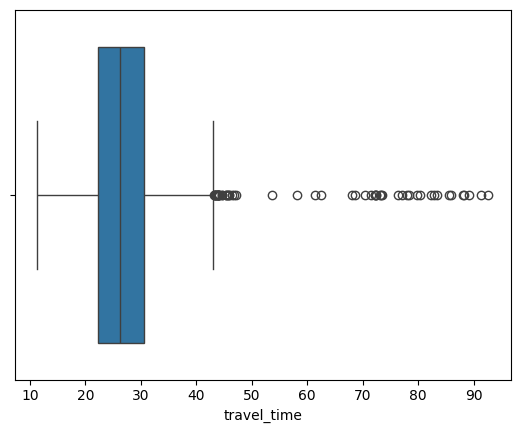

In [10]:
sns.boxplot(data=train_df, x='travel_time')

In [12]:
train_df = train_df.drop(train_df[train_df['travel_time'] > 80].index)

print(train_df.shape[0])

4989


5.

In [13]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
print("--- 처리 전 결측치 상태 ---")
print(train_df.isnull().sum())

train_df = train_df.dropna(subset=['weather'])
train_df['temperature'] = train_df['temperature'].fillna(train_df['temperature'].median())

print("--- 처리 후 결측치 상태 ---")
print(train_df.isnull().sum())

--- 처리 전 결측치 상태 ---
record_id             0
bus_route_id          0
date                  0
time                  0
day_of_week           0
bus_stop_id           0
temperature           2
weather               2
traffic_congestion    0
travel_time           0
month                 0
dtype: int64
--- 처리 후 결측치 상태 ---
record_id             0
bus_route_id          0
date                  0
time                  0
day_of_week           0
bus_stop_id           0
temperature           0
weather               0
traffic_congestion    0
travel_time           0
month                 0
dtype: int64


In [14]:
print(train_df['temperature'].median())

21.06449303125


6.

In [15]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
map_6 = {'Low': 0, 'Medium': 1, 'High': 2, 'Severe': 3}
train_df['traffic_congestion'] = train_df['traffic_congestion'].map(map_6)
test_df['traffic_congestion'] = test_df['traffic_congestion'].map(map_6)

train_df = pd.get_dummies(train_df, columns=['weather', 'day_of_week'], drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=['weather', 'day_of_week'], drop_first=True, dtype=int)

7.

In [16]:
# 이 코드를 먼저 실행하세요.
cols_to_drop = ['date', 'time', 'record_id', 'bus_route_id', 'bus_stop_id']

In [18]:
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

print(train_df.columns)

Index(['temperature', 'traffic_congestion', 'travel_time', 'month',
       'weather_Heavy Snow', 'weather_Rain', 'weather_Sunny',
       'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday'],
      dtype='object')


In [19]:
print(train_df.shape[1])

13


8.

In [22]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['travel_time'])
y = train_df['travel_time']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)

(3989, 12)


In [23]:
print(X_train.index)

Index([4866, 3021,  883, 1955, 2794, 4407, 1459, 2425, 1189, 3020,
       ...
       1693,  132, 2929, 3182, 3456, 4439,  469, 3103, 3784,  864],
      dtype='int64', length=3989)


9.

In [24]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"X_train_scaled 평균: {X_train_scaled.mean():.2f}")
print(f"X_train_scaled 표준편차: {X_train_scaled.std():.2f}")

X_train_scaled 평균: -0.00
X_train_scaled 표준편차: 1.00


10.

In [25]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_val_scaled)
pred_rf = rf.predict(X_val_scaled)

from sklearn.metrics import root_mean_squared_error
rmse_lr = root_mean_squared_error(y_val, pred_lr)
rmse_rf = root_mean_squared_error(y_val, pred_rf)

print(f"LinearRegression RMSE: {round(rmse_lr,4)}")
print(f"RandomForest RMSE: {round(rmse_rf,4)}")

LinearRegression RMSE: 4.7454
RandomForest RMSE: 4.7611


11.

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

In [27]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
dl_model = Sequential()
dl_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dropout(0.3))
dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.2))
dl_model.add(Dense(8, activation='relu'))
dl_model.add(Dense(1, activation='linear'))

dl_model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5)
mc = ModelCheckpoint(filepath='best_dl_model.keras', monitor='val_loss', save_best_only=True)

history = dl_model.fit(X_train_scaled, y_train,
                        epochs=50, batch_size=32,
                        validation_data=(X_val_scaled, y_val),
                        callbacks=[es,mc])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 522.8582 - val_loss: 129.9793
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 92.0736 - val_loss: 33.4971
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 72.7087 - val_loss: 28.3139
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 63.6879 - val_loss: 25.7732
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 61.9388 - val_loss: 25.4819
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 56.8661 - val_loss: 25.1324
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 51.5580 - val_loss: 25.5996
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50.7187 - val_loss: 24.4167
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 46.8467 - val_loss: 25.9307
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47.8197 - val_loss: 25.3125
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 46.8838 - val_loss: 25.3871
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━

12.

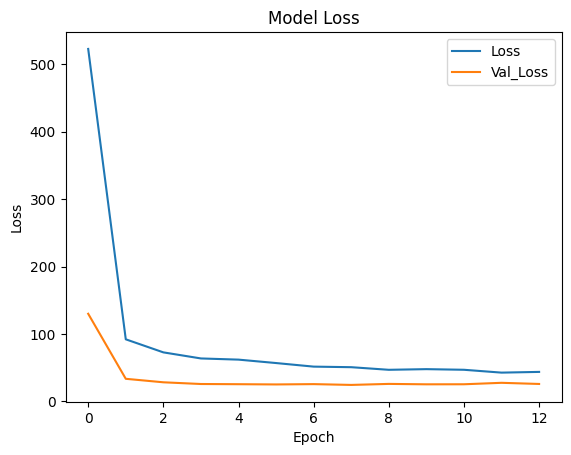

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Loss', 'Val_Loss'])
plt.show()

13.

In [29]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from tensorflow.keras.models import load_model

X_test = test_df.drop('travel_time', axis=1)
y_test = test_df['travel_time']
X_test = X_test[X_train.columns]

X_test_scaled = scaler.transform(X_test)
loaded_model = load_model('best_dl_model.keras')

final_mse = loaded_model.evaluate(X_test_scaled, y_test)
print(f"최종 테스트 데이터 MSE: {round(final_mse, 4)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31.1072
최종 테스트 데이터 MSE: 31.1072


14.

In [30]:
# 이 코드를 먼저 실행하세요.
# 새로운 운행 조건 데이터 (temperature, traffic_congestion 등 12개 피처)
new_data = np.array([[
    22.5, 2, 6, 0, 1, 0, 1, 0, 0, 0, 0, 0
]])

In [34]:
new_data_scaled = scaler.transform(new_data)

pred = loaded_model.predict(new_data_scaled)

print(round(pred.item(), 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
32.9


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
